In [1]:
import pandas as pd
import numpy as np
from numpy import mean
from numpy import exp
from numpy import inf
from scipy.integrate import quad 

In [2]:
# Randomly Sampling Using NumPy
# Generate random numbers from a Gaussian distribution
mean = 0
std_dev = 1
n = 1000
samples = np.random.normal(mean, std_dev, n)
samples[0:10]

array([ 1.55191629,  0.52829199, -1.60960273, -0.75455967, -0.0259295 ,
       -0.1856662 , -1.64005554, -1.20476564,  0.21892817,  0.26307233])

In [3]:
mu_hat = (1/n) * np.sum(samples)
sigma_hat = np.sqrt((1/(n-1)) * np.sum((samples - mu_hat)**2))
print(f'mu_hat= {mu_hat}, and sigma_hat= {sigma_hat}')

mu_hat= 0.010332981754945111, and sigma_hat= 1.0090475538708052


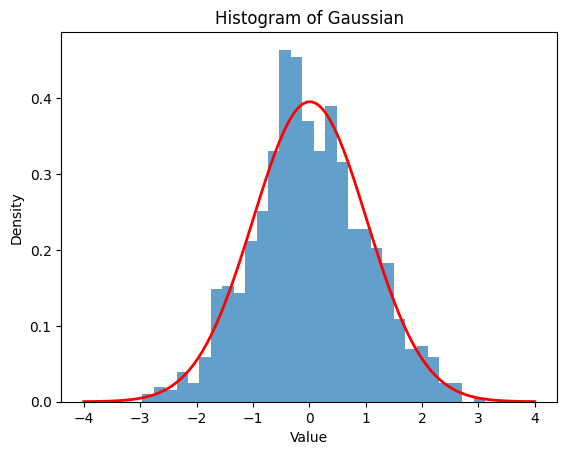

In [4]:
import matplotlib.pyplot as plt

def norm_pdf(x, mu, sigma):
    return 1/np.sqrt(2*np.pi*(sigma**2)) * np.exp(- (x - mu)**2 / (2*(sigma**2)))

plt.hist(samples, bins=30, density=True, alpha=.7)
x = np.linspace(-4, 4, 100)
y = norm_pdf(x, mu_hat, sigma_hat)
plt.plot(x, y, color='red', linewidth=2)

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram of Gaussian')
plt.show()

In [5]:
# Other Common Distributions to Try
# Exponential
# samples = np.random.exponential(scale=1/lambda, size=1000)
# Categorical
# samples = np.random.choice(category_range, n, p=probabilities)
# Uniform
# samples = np.random.rand(a, b)
# Poisson
# samples = np.random.poisson(lambda, size=1000)

# Rejection Sampling Example

- Goal is to generate samples from $p(y)$
- Can't do it directly, so we propose from $q(y)$

Steps:

1. Pick a constant $k$ such that $kq(y) > p(y)$
2. Sample from the proposal distribution, call this sample $v$
3. Generate a uniform random value, $u \sim Unif(0, kq(v))$
   - We can do this in python very easily by multiplying `k*q(v)*rand()`
4. If $u < p(v)$, we accept the sample and go back to Step 1. If it is not, we throw it away and go back to Step 1.

In [6]:
from scipy.stats import chi2, expon
from numpy.random import rand

# let us propose from an exponential distribution with some preset values
def q(y):
    return expon.pdf(y, loc=0, scale=6)

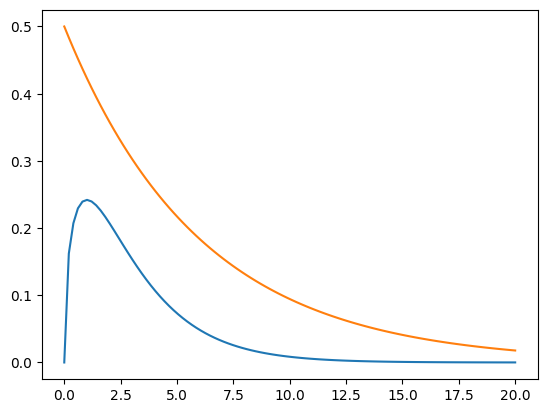

In [7]:
# suppose we want to sample from a chi square distribution 
# (the chi square is common, and there's no need to use rejection sampling...
# , but we can use it for example purposes...)
def p(y):
    return chi2.pdf(y, 3)

# Verify that the proposal is above the target distribution
# set k (later, see what happens if k is too small; say .5)
k = 3
y = np.linspace(0, 20, 100)
p1 = p(y)
p2 = k*q(y)

plt.plot(y,p1)
plt.plot(y,p2)
plt.show()

In [8]:
# let's do rejection sampling!
def rejection_sampling(n):
    samples = []
    while len(samples) < n:
        v = expon.rvs(loc=0, scale=6) # this samples a random value from the proposal dist
        if k*q(v)*rand() < p(v): # this flips the coin using rand() and sees if the proposed sample is good
            samples.append(v)

    return samples

In [9]:
rej_samples = rejection_sampling(1000)

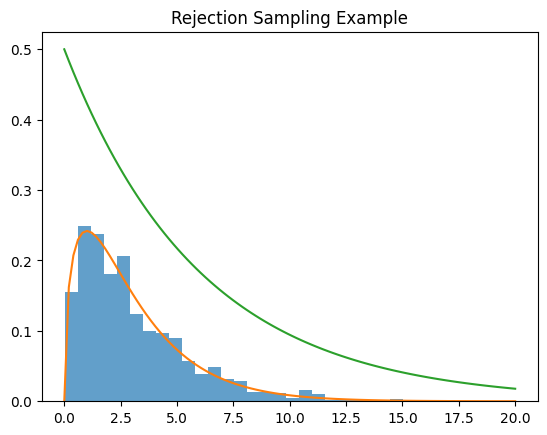

In [10]:
# Show the sampling worked
plt.hist(rej_samples, density=True, bins=30, alpha=0.7)
plt.plot(y,p1)
plt.plot(y,p2)
plt.title('Rejection Sampling Example')
plt.show()

# Ancestral Sampling Example

In [11]:
# ancestral sampling to generate from p(y,theta)
alpha = 1
beta = 1
n = 10000 # let's generate 10000 samples

# easy enough to sample from a beta
theta_samples = np.random.beta(alpha, beta, n)

In [12]:
# once we have theta samples, easy enough to sample from a bernoulli
y_samples = np.random.binomial(1, theta_samples)

In [13]:
# visualize the joint distribution
# remember that y in {0,1}
# and that 0 <= theta <= 1
# SO: make a heatmap
heatmap, xedges, yedges = np.histogram2d(
    theta_samples, y_samples, 
    bins=[100, 2],  # 100 bins for theta, 2 bins for y (0 and 1)
    range=[[0, 1], [-0.5, 1.5]]  # theta: [0, 1], y: [-0.5, 1.5]
)
heatmap = heatmap.T

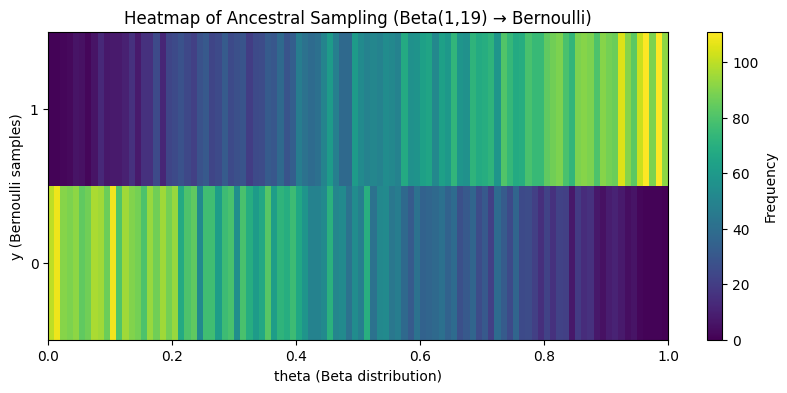

In [14]:
plt.figure(figsize=(10, 4))
plt.imshow(
    heatmap, 
    extent=[0, 1, -0.5, 1.5],  # Axis limits (x: theta, y: y)
    aspect="auto", 
    cmap="viridis", 
    origin="lower"  # Ensure y=0 is at the bottom
)
plt.colorbar(label="Frequency")
plt.xlabel("theta (Beta distribution)")
plt.ylabel("y (Bernoulli samples)")
plt.yticks([0, 1], ["0", "1"])  # Label y-axis with y=0 and y=1
plt.title("Heatmap of Ancestral Sampling (Beta(1,19) → Bernoulli)")
plt.show();

In [15]:
# We can visualize true joint distribution
# the likelihood
def py(y, theta):
    return (theta**y) * (1 - theta)**(1 - y)

# define a Beta function
import math
def Beta(x, y):
    return math.factorial(x-1)*math.factorial(y-1)/math.factorial(x+y-1)

# the prior
def ptheta(theta, alpha, beta):
    return theta**(alpha-1) * (1 - theta)**(beta - 1) / Beta(alpha, beta)

# the joint
def pytheta(theta, y, alpha, beta):
    return py(y, theta) * ptheta(theta, alpha, beta)

In [16]:
grid = np.linspace(0.001, .999, 100)
Z0 = pytheta(grid, 0, alpha=1, beta=1)
Z1 = pytheta(grid, 1, alpha=1, beta=1)
Z = np.vstack([Z1, Z0])

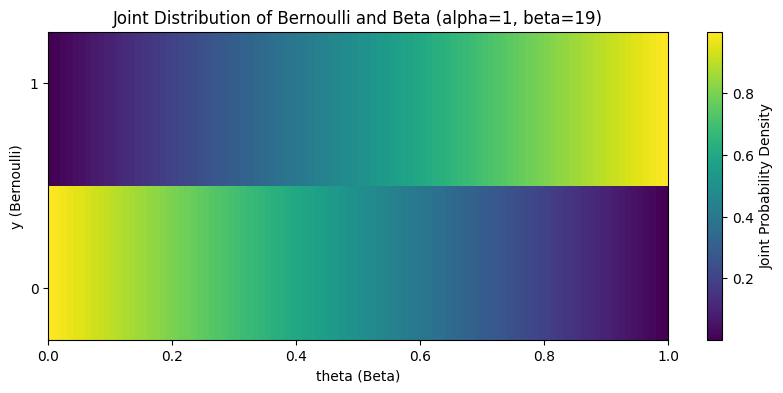

In [17]:
plt.figure(figsize=(10, 4))
plt.imshow(Z, extent=[0, 1, 0.25, 1.75], aspect='auto', cmap='viridis', origin='upper')
cbar = plt.colorbar()
cbar.set_label('Joint Probability Density')
plt.xlabel('theta (Beta)')
plt.ylabel('y (Bernoulli)')
plt.yticks([0.5, 1.5], ['0', '1'])
plt.title(f'Joint Distribution of Bernoulli and Beta (alpha={1}, beta={19})')
plt.show();
# Looks like our ancestral samples did a pretty good job huh?

In [18]:
# for the posterior, once we know y=0 or y=1, we can keep only those samples in the joint
# distribution for which y=0 (for example, if y=0) and then average over those theta values
# to get the posterior mean
theta_giveny0 = np.array(theta_samples)[np.array(y_samples)==0]
theta_giveny1 = np.array(theta_samples)[np.array(y_samples)==1]

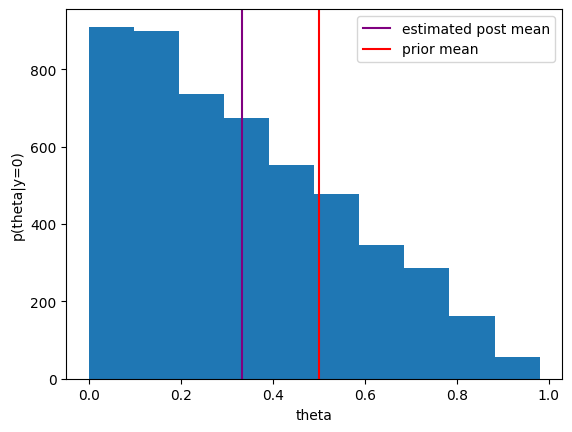

In [19]:
plt.hist(theta_giveny0)
plt.axvline(x=theta_giveny0.mean(), color = 'purple', label = 'estimated post mean') # add the E(theta|y=0) line
plt.axvline(x=1/2, color = 'red', label = 'prior mean')
plt.xlabel('theta')
plt.ylabel('p(theta|y=0)')
plt.legend()
plt.show();

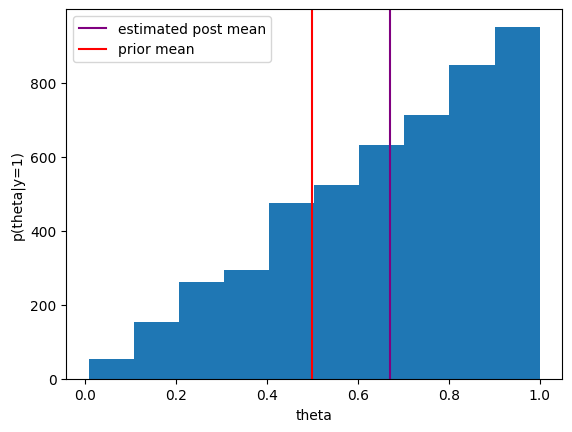

In [20]:
plt.hist(theta_giveny1)
plt.axvline(x=theta_giveny1.mean(), color = 'purple', label = 'estimated post mean') # add the E(theta|y=1) line
plt.axvline(x=1/2, color = 'red', label = 'prior mean')
plt.xlabel('theta')
plt.ylabel('p(theta|y=1)')
plt.legend()
plt.show();

In [21]:
# the estimated posterior means vs. the true posterior means
print(f'The estimated posterior mean when y=0: {theta_giveny0.mean()} vs. true post mean: {1/3}')
print(f'The estimated posterior mean when y=1: {theta_giveny1.mean()} vs. true post mean: {2/3}')

The estimated posterior mean when y=0: 0.33356416387188637 vs. true post mean: 0.3333333333333333
The estimated posterior mean when y=1: 0.6704105788334465 vs. true post mean: 0.6666666666666666


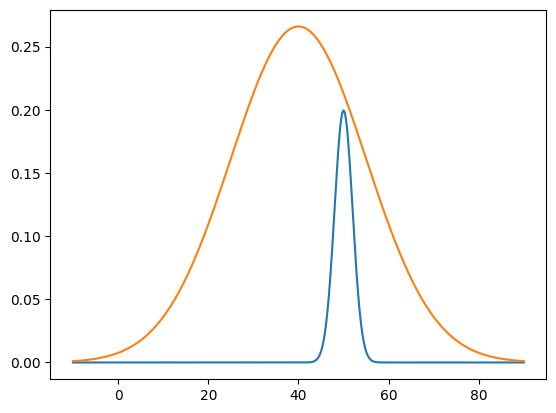

In [22]:
# Practice Solutions
# Normal Model (with known variance)
def norm_pdf(y, mu, sigma=1):
    return 1/np.sqrt(2*np.pi*(sigma**2)) * np.exp(- (y - mu)**2 / (2*(sigma**2)))

# (borrowing from HW 5 Song Popularity problem)
# Want to generate samples of mu|y to approximate the posterior
# Set up the prior mu ~ N(eta, tau)
eta = 50
tau = 2

# While we could use numpy to sample, let's use rejection sampling (to practice)
# let us propose from a normal with 
def q(y):
    return norm_pdf(y, mu=40, sigma=15)

def p(y):
    return norm_pdf(y, mu=eta, sigma=tau)

# Verify that the proposal is above the target distribution
# set k
k = 10
mu = np.linspace(-10, 90, 1000)
p1 = p(mu)
p2 = k*q(mu)

plt.plot(mu,p1)
plt.plot(mu,p2)
plt.show()

In [23]:
# let's do rejection sampling!
def rejection_sampling(n):
    samples = []
    while len(samples) < n:
        v = np.random.normal(40, 15) # this samples a random value from the proposal dist
        if k*q(v)*rand() < p(v): # this flips the coin using rand() and sees if the proposed sample is good
            samples.append(v)

    return samples

In [24]:
mu_samples = rejection_sampling(100000)

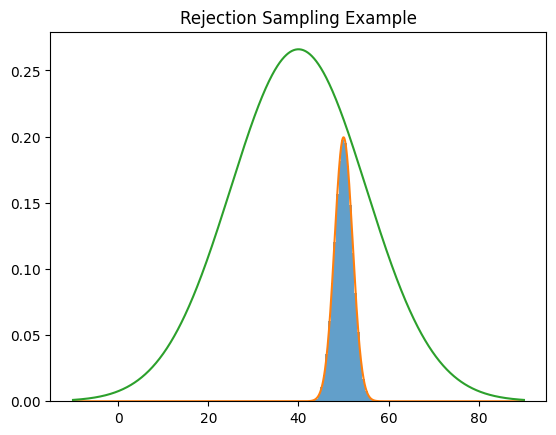

In [25]:
# Show the sampling worked
plt.hist(mu_samples, density=True, bins=30, alpha=0.7)
plt.plot(mu,p1)
plt.plot(mu,p2)
plt.title('Rejection Sampling Example')
plt.show()

In [26]:
# Now that you have samples from mu, we will use them to generate samples from y
# This time, let's just use numpy:
y_samples = np.random.normal(loc=mu_samples, scale = 1)
(y_samples.min(), y_samples.max())

(np.float64(40.04210698835735), np.float64(59.90314493001252))

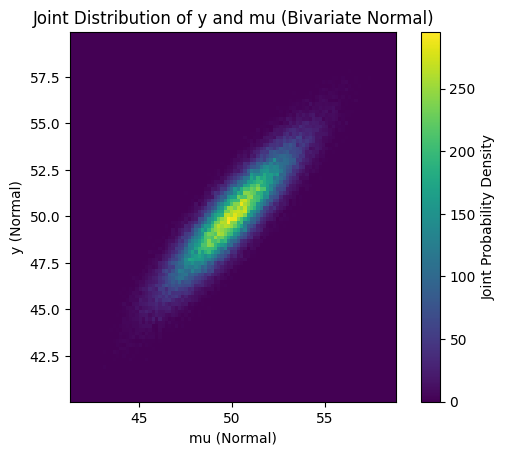

In [27]:
# visualize the joint distribution
heatmap, xedges, yedges = np.histogram2d(mu_samples, y_samples, bins=100)
bounds = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

plt.clf()
plt.imshow(heatmap.T, extent=bounds, origin='lower')
cbar = plt.colorbar()
cbar.set_label('Joint Probability Density')
plt.xlabel('mu (Normal)')
plt.ylabel('y (Normal)')
plt.title(f'Joint Distribution of y and mu (Bivariate Normal)')
plt.show();

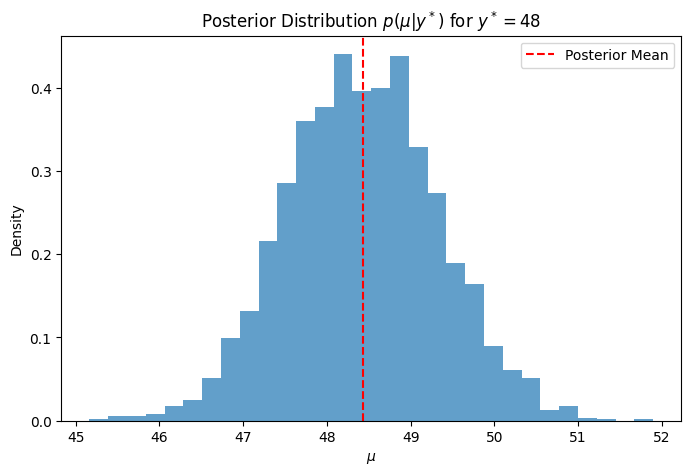

In [28]:
# How to find the estimated conditional posterior, p(mu|y), for a single sample y?
# Since y is continuous, there are several different ways
# One way is to empirically estimate given a tolerance (though this requires MANY samples):
# Choose a specific y value (for posterior conditioning)
y_star = 48
tolerance = 0.1  # Accept samples where y is within this range

# Extract mu samples where y is close to y_star
mu_given_y = np.array(mu_samples)[np.abs(y_samples - y_star) < tolerance]

# Plot the posterior distribution p(mu | y_star)
plt.figure(figsize=(8, 5))
plt.hist(mu_given_y, density=True, bins=30, alpha=0.7)
plt.axvline(x=np.mean(mu_given_y), color='red', linestyle='--', label="Posterior Mean")
plt.xlabel(r"$\mu$")
plt.ylabel(r"Density")
plt.title(r"Posterior Distribution $p(\mu | y^*)$ for $y^* = 48$")
plt.legend()
plt.show();

True posterior mean = 48.4 vs. Estimated posterior mean = 48.43112893166605


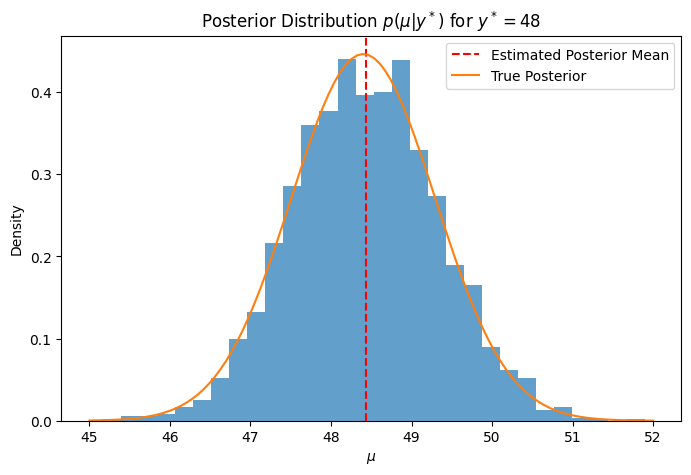

In [29]:
# we can compare this to the TRUE posterior, since we know that formula
known_sigma = 1
true_post_mu = ((y_star/known_sigma**2) + (eta/tau**2)) / ((1/known_sigma**2) + (1/tau**2))
true_post_sigma = np.sqrt( ((1/known_sigma**2) + (1/tau**2))**(-1) )
print(f'True posterior mean = {true_post_mu} vs. Estimated posterior mean = {mu_given_y.mean()}')

mu_range = np.linspace(45, 52, 100)
plt.figure(figsize=(8, 5))
plt.hist(mu_given_y, density=True, bins=30, alpha=0.7)
plt.axvline(x=np.mean(mu_given_y), color='red', linestyle='--', label="Estimated Posterior Mean")
plt.plot(mu_range, norm_pdf(mu_range, mu = true_post_mu, sigma = true_post_sigma), label = "True Posterior")
plt.xlabel(r"$\mu$")
plt.ylabel(r"Density")
plt.title(r"Posterior Distribution $p(\mu | y^*)$ for $y^* = 48$")
plt.legend()
plt.show();

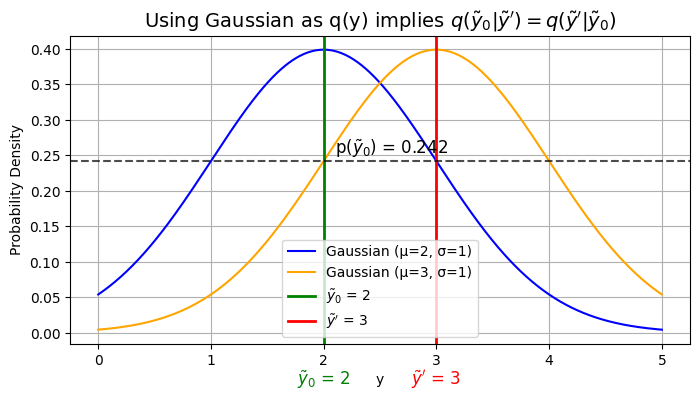

In [30]:
# MCMC
# Metropolis-Hastings
from scipy.stats import norm

# Plot for illustration purposes
# Parameters for the Gaussian distributions
mu1 = 2  # Mean of the first Gaussian (blue)
mu2 = 3  # Mean of the second Gaussian (orange)
sigma = 1  # Standard deviation (same for both Gaussians)

# Points of interest
y0 = 2  # Green vertical line at y = 2 (center of first Gaussian)
y_prop = 3  # Red vertical line at y = 3 (center of second Gaussian)

# Generate data points for the Gaussians
y_values = np.linspace(0, 5, 1000)
p1_values = norm.pdf(y_values, mu1, sigma)  # First Gaussian (blue)
p2_values = norm.pdf(y_values, mu2, sigma)  # Second Gaussian (orange)

# Create the plot
plt.figure(figsize=(8, 4))

# Plot the Gaussian distributions
plt.plot(y_values, p1_values, label=f'Gaussian (μ={mu1}, σ={sigma})', color='blue')
plt.plot(y_values, p2_values, label=f'Gaussian (μ={mu2}, σ={sigma})', color='orange')

# Draw a green vertical line at y = 2 and label it as y_0
plt.axvline(x=y0, color='green', linestyle='-', linewidth=2, label=r'$\tilde{y}_0$ = 2')
plt.text(y0, -0.05, r'$\tilde{y}_0$ = 2', fontsize=12, color='green', ha='center', va='top')

# Draw a red vertical line at y = 3 and label it as y'
plt.axvline(x=y_prop, color='red', linestyle='-', linewidth=2, label=r"$\tilde{y}'$ = 3")
plt.text(y_prop, -0.05, r"$\tilde{y}'$ = 3", fontsize=12, color='red', ha='center', va='top')

# Find the intersection of the green vertical line (y0=2) with the ORANGE Gaussian (mu=3)
p_y0_orange = norm.pdf(y0, mu2, sigma)  # p(y) at y=2 for the orange Gaussian

# Draw a dashed horizontal line at this intersection
plt.axhline(y=p_y0_orange, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.text(y0 + 0.1, p_y0_orange + 0.01, r'p($\tilde{y}_0$) = 0.242', fontsize=12, color='black')

# Add labels, title, and legend
plt.xlabel('y')
plt.ylabel('Probability Density')
plt.title(r"Using Gaussian as q(y) implies $q(\tilde{y}_0|\tilde{y}') = q(\tilde{y}'|\tilde{y}_0)$", fontsize=14)
plt.legend()

# Show the plot
plt.grid(True)
plt.show();

In [31]:
# How to generate an Isotropic Gaussian Sample
mu = np.array([0, 0])
sigma = 1.0
d = mu.shape[0]

sample = np.random.normal(loc=mu, scale=sigma, size=(1,d))
sample

array([[ 0.82730931, -0.44322984]])

In [32]:
# Banana Example
def banana_p(y1, y2):
    return np.exp(-((y1**2 + y2**2 - .5)**2 / .5) - ((y2 - y1**2 + 1)**2 / 1.5))

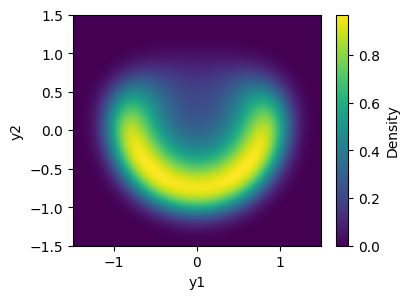

In [33]:
# Create a grid for the theoretical banana distribution
y1_range = np.linspace(-1.5, 1.5, 100)
y2_range = np.linspace(-1.5, 1.5, 100)
Y1, Y2 = np.meshgrid(y1_range, y2_range)
# grid = np.column_stack([Y1.ravel(), Y2.ravel()])

p_values = banana_p(Y1, Y2).reshape(100, 100)

# make the plot using matplotlib
plt.figure(figsize=(4, 3))
plt.imshow(p_values, extent=[-1.5, 1.5, -1.5, 1.5], origin='lower', cmap="viridis", aspect='auto')
plt.xlabel("y1")
plt.ylabel("y2")
plt.colorbar(label="Density")
plt.show()

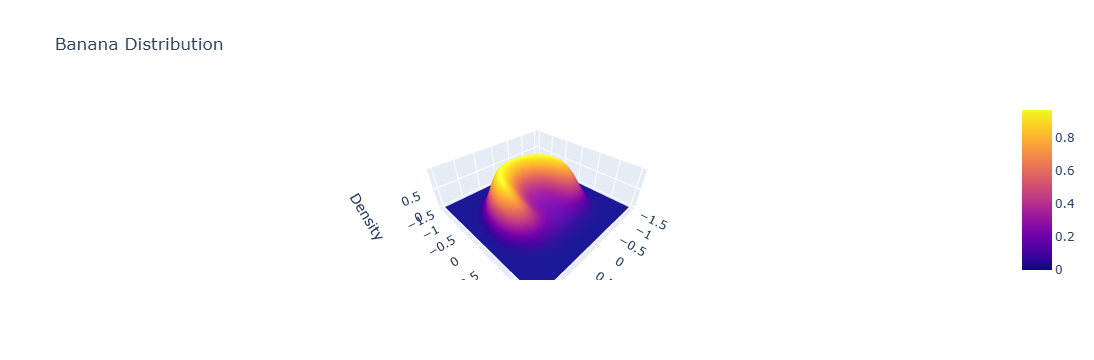

In [34]:
import plotly.graph_objects as go
fig = go.Figure(data=[go.Surface(z=p_values, x=Y1, y=Y2)])
fig.update_layout(title="Banana Distribution", scene=dict(xaxis_title="y1", yaxis_title="y2", zaxis_title="Density"))
fig.show();

In [35]:
# define the metropolis algorithm
def metropolis_sampling(n=10000, sigma=1.25, burn=.18):
    samples = [] # keep track of samples
    y1, y2 = 0.0, 0.0  # Start from the origin
    total_samples = int(n / (1 - burn))
    m = int(total_samples*burn) # discard amount
    accepted = 0 # keep track of acceptances

    while len(samples) < total_samples:
        y1_prop, y2_prop = np.random.normal(y1, sigma), np.random.normal(y2, sigma)
        alpha = banana_p(y1_prop, y2_prop) / banana_p(y1, y2)
        
        if np.random.rand() < alpha:
            y1, y2 = y1_prop, y2_prop
            accepted += 1

        # "Rejecting" the proposed sample is the same as accepting the old one again
        samples.append([y1, y2])

    # calculate acceptance rate (should be ideally about 23.4% (fiddle with sigma to make it at least between .2 and .5)
    acceptance_rate = accepted / total_samples
    print(f'Acceptance rate: {acceptance_rate:.3f}')
    
    samples = samples[m:] # Discard 18% of the initial samples
    return np.array(samples)

# generate the samples
samples = metropolis_sampling()
print(len(samples)) # verify there are 10000

Acceptance rate: 0.226
10000


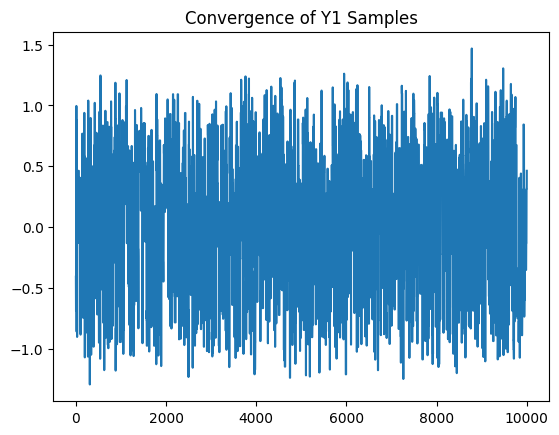

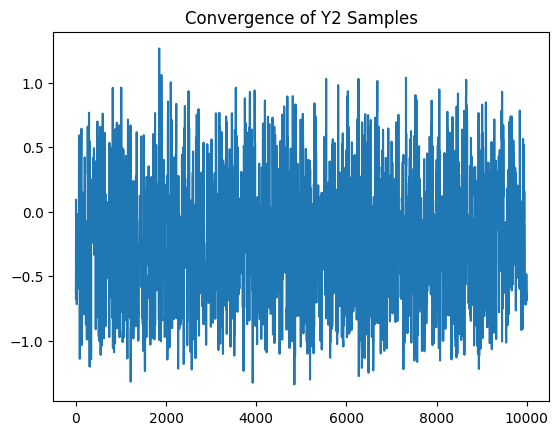

In [36]:
# check convergence with plots
# in this case, it should converg very quickly, since the starting samples were reasonable and this is not too complex a distribution
# try changing the starting values in the metropolis_sampling function (and not discarding) to see
plt.plot(samples[:,0])
plt.title(label='Convergence of Y1 Samples')
plt.show();
plt.plot(samples[:,1])
plt.title(label='Convergence of Y2 Samples')
plt.show();

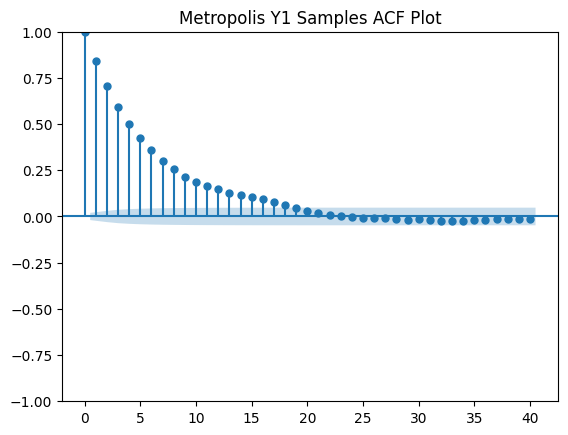

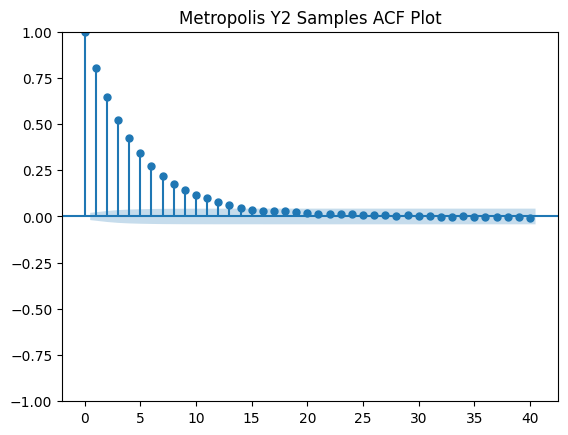

In [37]:
# check ACF plots to determine if mixing well (even if not, we won't do anything about it)
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(samples[:,0], title = 'Metropolis Y1 Samples ACF Plot')
plt.show();
plot_acf(samples[:,1], title = 'Metropolis Y2 Samples ACF Plot')
plt.show();
# plots below suggest chain is relatively slow mixing; we would like to ideally have very little
# correlation between samples, so we should consider sampling more points and then thinning

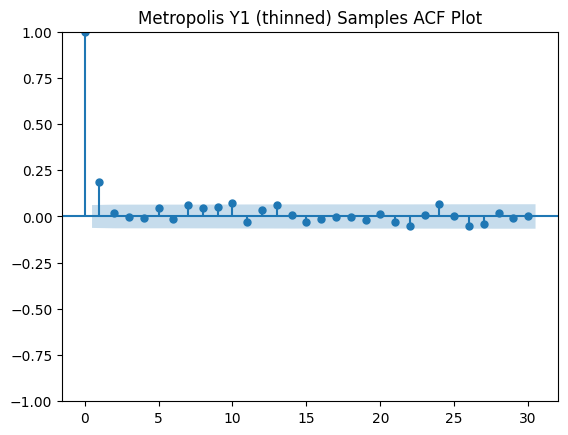

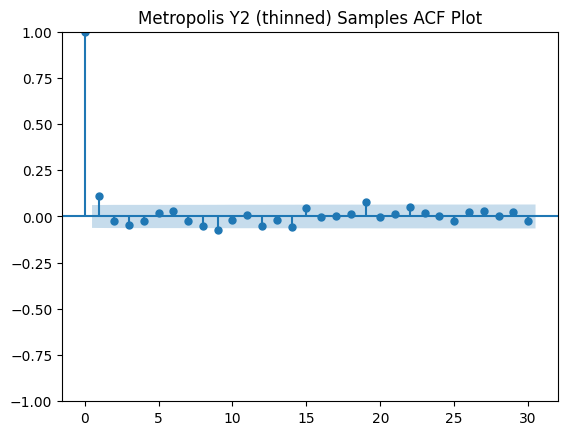

In [38]:
## If you want to thin (say, keep only every 10th sample)
thinned_samples = samples[::10] # keeps every 10th
## Should show better mixing
plot_acf(thinned_samples[:,0], title = 'Metropolis Y1 (thinned) Samples ACF Plot')
plt.show();
plot_acf(thinned_samples[:,1], title = 'Metropolis Y2 (thinned) Samples ACF Plot')
plt.show();

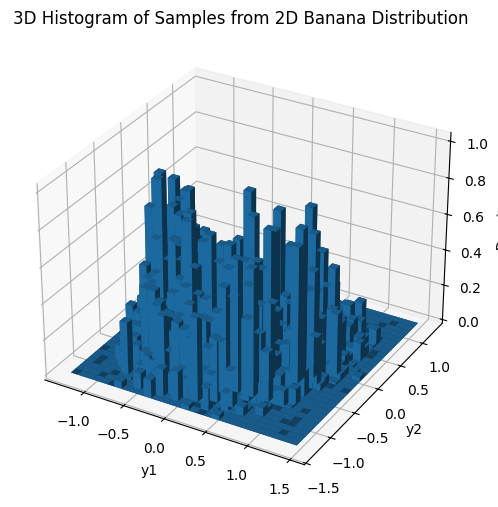

In [39]:
# one way to create a 3D histogram
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

hist, xedges, yedges = np.histogram2d(samples[:, 0], samples[:, 1], bins=30, density=True)
## With thinned samples
# hist, xedges, yedges = np.histogram2d(thinned_samples[:, 0], thinned_samples[:, 1], bins=30, density=True)
xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1], indexing="ij")

xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = np.zeros_like(xpos)
dx = dy = np.ones_like(zpos) * (xedges[1] - xedges[0])
dz = hist.ravel()

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True)
ax.set_xlabel("y1")
ax.set_ylabel("y2")
ax.set_zlabel("Density")
ax.set_title("3D Histogram of Samples from 2D Banana Distribution")
plt.show();

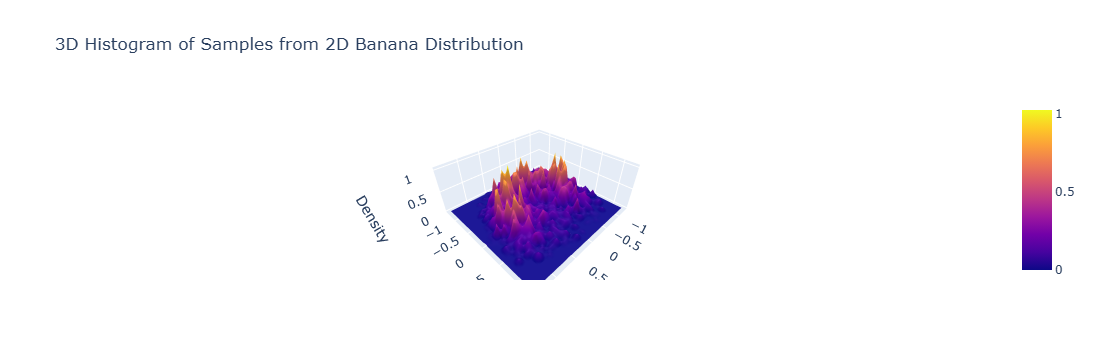

In [40]:
# to use plotly so that it is interactive, though requires some slight smoothing:
# Define the bin centers
xpos, ypos = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, 
                         (yedges[:-1] + yedges[1:]) / 2, 
                         indexing="ij")

fig = go.Figure(data=[go.Surface(z=hist, x=xpos, y=ypos)])

fig.update_layout(title="3D Histogram of Samples from 2D Banana Distribution", scene=dict(xaxis_title="y1", yaxis_title="y2", zaxis_title="Density"))

fig.show();

In [41]:
from scipy.stats import multivariate_normal

# Bayesian Metropolis
# the likelihood
Sigma = np.array([[1, 1],
                  [1, 2]])
def likelihood(y, mu):
    return multivariate_normal.pdf(y, mean=mu, cov=Sigma)

# the prior
mu0 = np.array([0, 0])
Sigma0 = np.array([[1, 0],
                   [0, 1]])
def prior(mu):
    return multivariate_normal.pdf(mu, mean=mu0, cov=Sigma0)

# and the joint we'll sample from
def p(y, mu):
    return likelihood(y, mu)*prior(mu)

# define the metropolis algorithm
# we're sampling from a 4 dimensional thing, so we need a four dimensional proposal
# we'll need LOTS of samples to make this work (so this will take a while)
def metropolis_sampling(n=100000, sigma=0.5, burn=.18):
    samples = []
    y1, y2, mu1, mu2 = 0.0, 0.0, 0.0, 0.0  # Start at zeros
    total_samples = int(n / (1 - burn))
    m = int(total_samples*burn) # discard amount
    accepted = 0 # keep track of acceptances

    while len(samples) < total_samples:
        y1_prop, y2_prop, mu1_prop, mu2_prop = (np.random.normal(y1, sigma), 
                                                np.random.normal(y2, sigma), 
                                                np.random.normal(mu1, sigma), 
                                                np.random.normal(mu2, sigma))
        alpha = p(np.array([y1_prop, y2_prop]), np.array([mu1_prop, mu2_prop])) / p(np.array([y1, y2]), np.array([mu1, mu2]))
        
        if np.random.rand() < alpha:
            y1, y2, mu1, mu2 = y1_prop, y2_prop, mu1_prop, mu2_prop
            accepted += 1
        
        samples.append([y1, y2, mu1, mu2])
            
    # calculate acceptance rate (should be ideally about 23.4% (fiddle with sigma to make it at least between .2 and .5)
    acceptance_rate = accepted / total_samples
    print(f'Acceptance rate: {acceptance_rate:.3f}')
    
    samples = samples[m:] # Discard 18% of the initial samples (can remove to see all samples)
    return np.array(samples)

# generate the samples
samples = metropolis_sampling()
print(len(samples)) # verify there are 100000

Acceptance rate: 0.551
100000


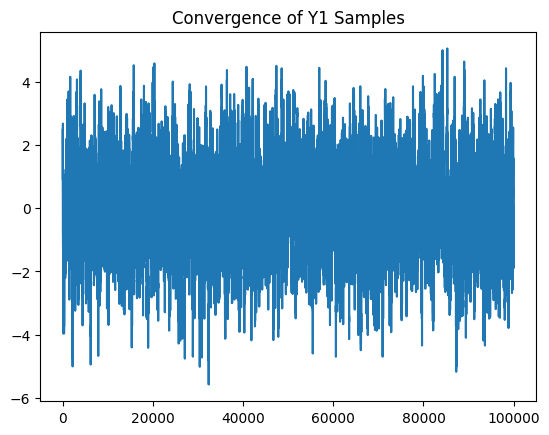

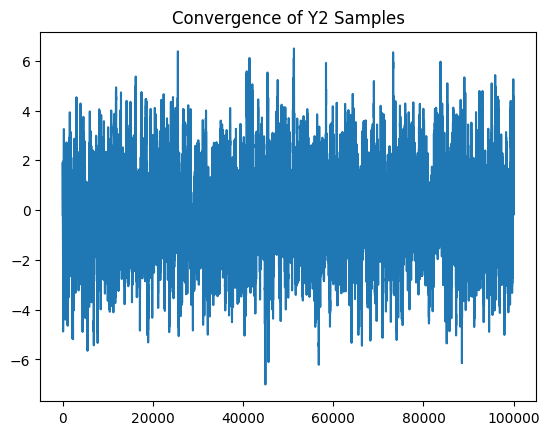

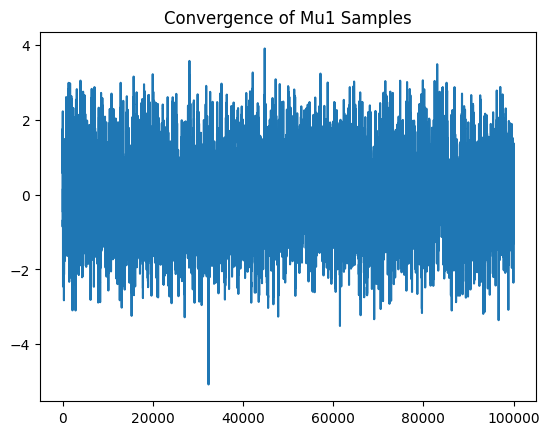

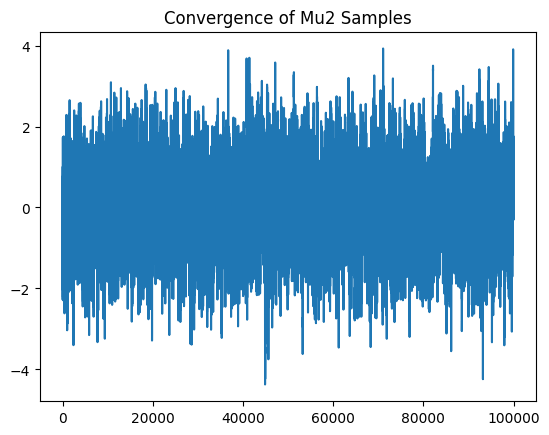

In [42]:
# check convergence with plots
# in this case, it should converg very quickly, since the starting samples were reasonable
plt.plot(samples[:,0])
plt.title(label='Convergence of Y1 Samples')
plt.show();
plt.plot(samples[:,1])
plt.title(label='Convergence of Y2 Samples')
plt.show();
plt.plot(samples[:,2])
plt.title(label='Convergence of Mu1 Samples')
plt.show();
plt.plot(samples[:,3])
plt.title(label='Convergence of Mu2 Samples')
plt.show();

In [43]:
# Chains are probably not mixing very well, but we'll ignore that issue for now
# Note I'm interested in the joint posterior of mu1,mu2 when y1,y2 = [3,2]
y_obs = np.array([3, 2])
tolerance = .5

# Extract mu samples where y is close to y_star
mu_given_y = samples[(np.abs(samples[:,0] - y_obs[0]) < tolerance) & (np.abs(samples[:,1] - y_obs[1]) < tolerance), 2:]

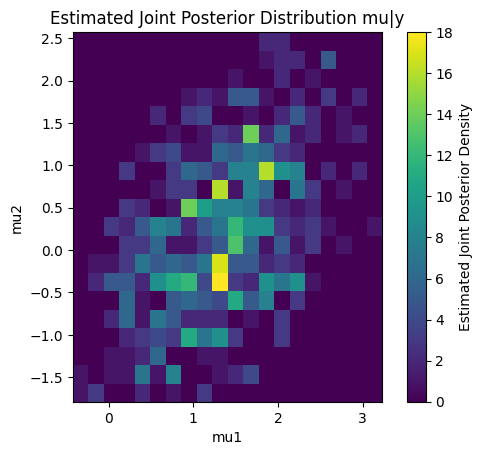

In [44]:
# visualize the joint posterior distribution of mu|y=[3,2]
heatmap, xedges, yedges = np.histogram2d(mu_given_y[:,0], mu_given_y[:,1], bins=20)
bounds = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

plt.clf()
plt.imshow(heatmap.T, extent=bounds, origin='lower')
cbar = plt.colorbar()
cbar.set_label('Estimated Joint Posterior Density')
plt.xlabel('mu1')
plt.ylabel('mu2')
plt.title(f'Estimated Joint Posterior Distribution mu|y')
plt.show();

In [45]:
# the estimated posterior means for the two mu
print(np.array(mu_given_y.mean(axis=0)).reshape(2,1))
# the true posterior means
# redefine the prior mu and observation for dimension reasons
mu0 = np.array([[0],[0]])
y_obs = np.array([[3], [2]])
true_post_mean = np.linalg.inv(np.linalg.inv(Sigma0) + np.linalg.inv(Sigma)).dot(np.linalg.inv(Sigma0).dot(mu0) + np.linalg.inv(Sigma).dot(y_obs))
print(true_post_mean)

[[1.32012601]
 [0.18397707]]
[[1.4]
 [0.2]]


In [46]:
# Gibbs Sampling Example
mu = np.array([[3],[2]])
Sigma = np.array([[1, 1],
                  [1, 2]])

# remember how to generate the conditional distribution of a multivariate Gaussian
# in this case, each one will be univariate normal
# we can define a function for the distribution of yi|yj, where j is index (0 or 1) of the known y
def pyigiven_yj(yj, j, mu, Sigma):
    i = (np.arange(len(mu))!=j)
    mu_a = mu[i,0][0]
    mu_b = mu[j,0]
    sigma_aa = Sigma[i,i][0]
    sigma_ab = Sigma[i,j][0]
    sigma_bb = Sigma[j,j]

    mu_agivenb = mu_a + sigma_ab*(1/sigma_bb)*(yj - mu_b)
    sigma_agivenb = sigma_aa - sigma_ab*(1/sigma_bb)*sigma_ab

    return np.random.normal(mu_agivenb, np.sqrt(sigma_agivenb))    

In [47]:
def gibbs_sampling(n, burn=.18):
    samples = [] # joint samples, initialize empty array
    y1, y2 = 0.0, 0.0 # initialize "randomly"
    total_samples = int(n / (1 - burn))
    m = int(total_samples*burn)
    
    while len(samples) < total_samples:
        y1 = pyigiven_yj(y2, 1, mu, Sigma)
        y2 = pyigiven_yj(y1, 0, mu, Sigma)
        samples.append([y1, y2])

    samples = samples[m:]
    return np.array(samples)

In [48]:
samples_gibbs = gibbs_sampling(100000)
samples_gibbs[:10,:]

array([[ 3.22754923,  3.76109954],
       [ 4.00341897,  1.84330535],
       [ 2.15597792, -2.34316042],
       [-0.00524099, -0.59652698],
       [ 2.08142204,  0.45115933],
       [ 1.7483248 , -0.10778488],
       [ 2.68618915,  1.77846684],
       [ 2.03194069, -0.36929464],
       [ 1.40595953,  0.56367675],
       [ 2.48415442,  2.12991029]])

In [49]:
print(samples_gibbs.mean(axis=0))
print(np.cov(samples_gibbs, rowvar=False))

[2.99970065 2.00380994]
[[1.00381514 1.00307593]
 [1.00307593 2.00728757]]


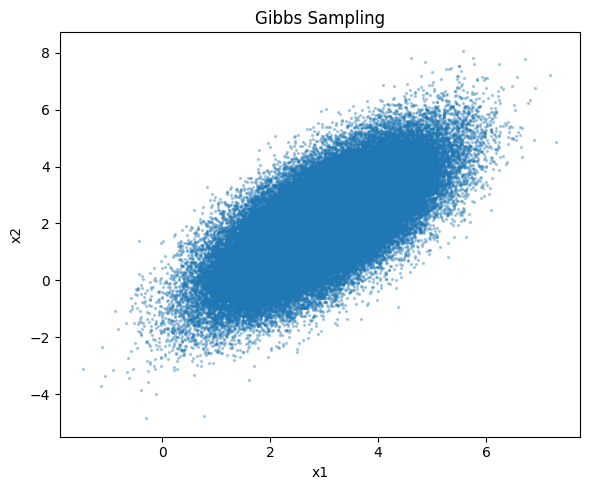

In [50]:
plt.figure(figsize=(6, 5))
plt.scatter(samples_gibbs[:, 0], samples_gibbs[:, 1], alpha=0.3, s=2)
plt.title("Gibbs Sampling")
plt.xlabel("x1")
plt.ylabel("x2")
plt.tight_layout()
plt.show()

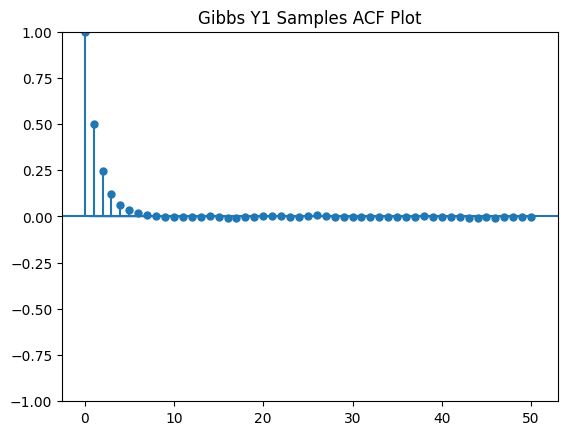

In [51]:
plot_acf(samples_gibbs[:,0], title = 'Gibbs Y1 Samples ACF Plot')
plt.show();

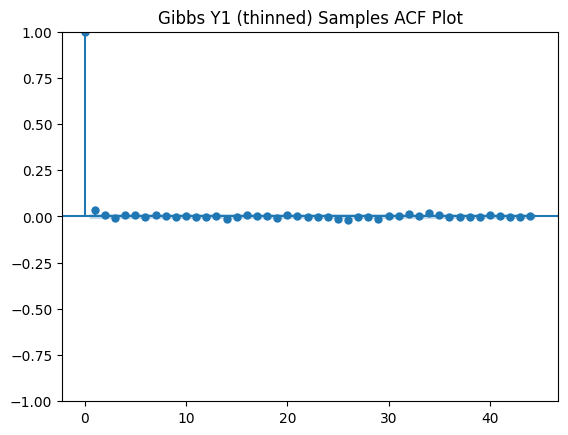

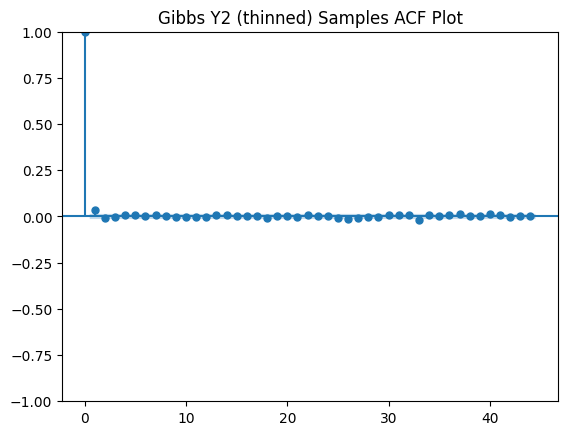

In [53]:
# practice thinning
thinned_samples = samples_gibbs[::5] # keeps every 5th
## Should show better mixing
plot_acf(thinned_samples[:,0], title = 'Gibbs Y1 (thinned) Samples ACF Plot')
plt.show();
plot_acf(thinned_samples[:,1], title = 'Gibbs Y2 (thinned) Samples ACF Plot')
plt.show();